# 01 · Exploración de bases de datos (Fase 1)
**Responsable:** Juan Pablo
**Objetivo:** explorar 3 bases de datos de 2 tipos distintos (tabular, texto e imágenes), documentar sus características y justificar la elección de la base final.

| # | Base de datos | Tipo | Fuente |
|---|---|---|---|
| 1 | Bank Marketing (UCI) | Tabular | Banco portugués, campañas telefónicas 2008-2010 |
| 2 | SMS Spam Collection (UCI) | Texto | Mensajes SMS etiquetados como spam / ham |
| 3 | Fashion-MNIST (Zalando) | Imágenes | Fotografías 28x28 de prendas de ropa |

In [1]:
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # para poder importar src/
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import (configurar_graficos, cargar_datos, guardar_figura,
                       VARIABLES_NUMERICAS, VARIABLES_CATEGORICAS, OBJETIVO,
                       RUTA_PROCESADOS)
configurar_graficos()
import gzip, io, urllib.request

## 1. Bank Marketing (tabular)
- **Fuente:** Moro, Cortez & Rita (2014). *A Data-Driven Approach to Predict the Success of Bank Telemarketing.* UCI Machine Learning Repository.
- **Tipo de fuente:** **secundaria** (los datos los recolectó el banco para su operación y los investigadores los publicaron; nosotros los reutilizamos).
- **Problema:** predecir si un cliente suscribe un depósito a plazo (`y`) después de una llamada de telemercadeo.

In [2]:
bank = cargar_datos()
print(f"Registros: {bank.shape[0]:,} | Atributos: {bank.shape[1]}")
print(f"Tamaño en memoria: {bank.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print(f"Numéricas: {bank.select_dtypes('number').shape[1]} | Categóricas: {bank.select_dtypes(exclude='number').shape[1]}")
bank.head()

Registros: 41,188 | Atributos: 21
Tamaño en memoria: 28.3 MB
Numéricas: 11 | Categóricas: 10


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,aug,thu,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0
1,53,technician,married,unknown,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,management,single,university.degree,no,yes,no,cellular,jun,thu,...,3,6,2,success,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,services,married,high.school,no,no,no,cellular,apr,fri,...,2,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,retired,married,basic.4y,no,yes,no,cellular,aug,fri,...,1,3,1,success,-2.9,92.201,-31.4,0.869,5076.2,1


In [3]:
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null  float64
 1

## 2. SMS Spam Collection (texto)
- **Fuente:** Almeida & Hidalgo (2011), UCI Machine Learning Repository.
- **Tipo de fuente:** **secundaria** (mensajes recolectados de foros y corpus públicos).
- **Problema:** clasificar mensajes de texto como *spam* o *ham* (legítimo).

In [4]:
URL_SMS = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
try:
    sms = pd.read_csv(URL_SMS, sep="\t", header=None, names=["etiqueta", "mensaje"])
    sms["n_caracteres"] = sms["mensaje"].str.len()
    sms["n_palabras"] = sms["mensaje"].str.split().str.len()
    print(f"Registros: {sms.shape[0]:,} | Atributos originales: 2 (etiqueta, mensaje)")
    print(f"Tamaño en memoria: {sms.memory_usage(deep=True).sum()/1024**2:.1f} MB")
    print("\nDistribución de clases (%):")
    print((sms["etiqueta"].value_counts(normalize=True) * 100).round(1))
    display(sms.groupby("etiqueta")[["n_caracteres", "n_palabras"]].mean().round(1))
except Exception as e:
    sms = None
    print("No se pudo descargar el dataset de SMS (sin internet):", e)

Registros: 5,572 | Atributos originales: 2 (etiqueta, mensaje)
Tamaño en memoria: 1.2 MB

Distribución de clases (%):
etiqueta
ham     86.6
spam    13.4
Name: proportion, dtype: float64


,n_caracteres,n_palabras
etiqueta,,
ham,71.5,14.3
spam,138.7,23.9


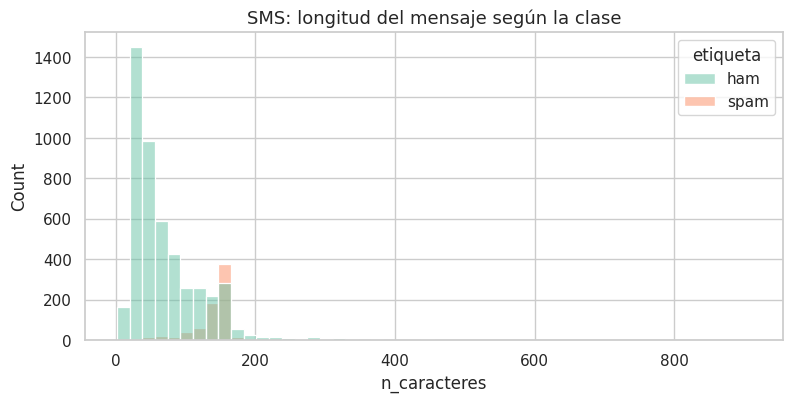

In [5]:
if sms is not None:
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(data=sms, x="n_caracteres", hue="etiqueta", bins=50, ax=ax)
    ax.set_title("SMS: longitud del mensaje según la clase")
    guardar_figura("01_sms_longitud")
    plt.show()

## 3. Fashion-MNIST (imágenes)
- **Fuente:** Xiao, Rasul & Vollgraf (2017), Zalando Research.
- **Tipo de fuente:** **secundaria** (imágenes del catálogo de Zalando procesadas por sus investigadores).
- **Problema:** clasificar la prenda de ropa (10 clases) a partir de una imagen en escala de grises de 28x28 píxeles.
- Se carga el conjunto de prueba (10.000 imágenes); el conjunto completo tiene 70.000.

In [6]:
BASE = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
CLASES = ["Camiseta", "Pantalón", "Suéter", "Vestido", "Abrigo",
          "Sandalia", "Camisa", "Tenis", "Bolso", "Botín"]

def leer_idx(url, offset):
    with urllib.request.urlopen(url) as r:
        datos = gzip.decompress(r.read())
    return np.frombuffer(datos, dtype=np.uint8, offset=offset)

try:
    X_img = leer_idx(BASE + "t10k-images-idx3-ubyte.gz", 16).reshape(-1, 28, 28)
    y_img = leer_idx(BASE + "t10k-labels-idx1-ubyte.gz", 8)
    print(f"Imágenes: {X_img.shape[0]:,} | Dimensión: {X_img.shape[1]}x{X_img.shape[2]} = {28*28} atributos (píxeles)")
    print(f"Tamaño en memoria: {X_img.nbytes/1024**2:.1f} MB")
    print("Imágenes por clase:", np.bincount(y_img))
except Exception as e:
    X_img = None
    print("No se pudo descargar Fashion-MNIST (sin internet):", e)

Imágenes: 10,000 | Dimensión: 28x28 = 784 atributos (píxeles)
Tamaño en memoria: 7.5 MB
Imágenes por clase: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


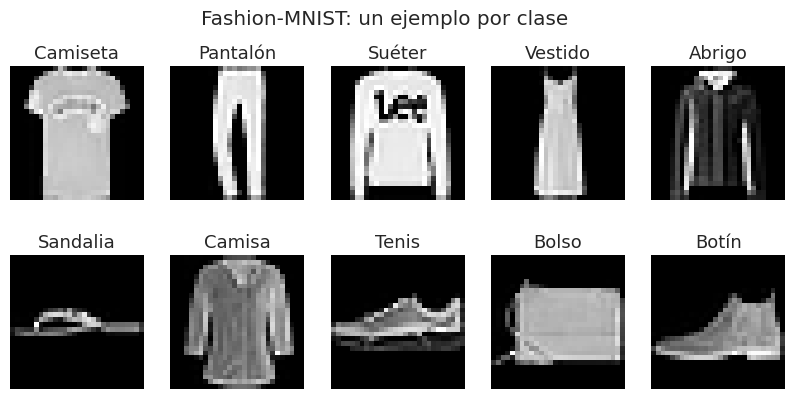

In [7]:
if X_img is not None:
    fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
    for clase, ax in enumerate(axes.flat):
        ax.imshow(X_img[y_img == clase][0], cmap="gray")
        ax.set_title(CLASES[clase]); ax.axis("off")
    plt.suptitle("Fashion-MNIST: un ejemplo por clase")
    guardar_figura("01_fashion_mnist_muestras")
    plt.show()

## 4. Comparación y selección de la base final
Se califica cada base de 1 (bajo) a 5 (alto) en los criterios pedidos: **completitud, relevancia, documentación y manejabilidad**. Se añade *riqueza para EDA* porque el evento pide analizar faltantes, atípicos, distribuciones y relaciones entre variables.

In [8]:
comparacion = pd.DataFrame({
    "Tipo":            ["Tabular", "Texto", "Imágenes"],
    "Tipo de fuente":  ["Secundaria", "Secundaria", "Secundaria"],
    "Registros":       ["41.188", "5.572", "70.000"],
    "Atributos":       ["20 + objetivo", "1 texto + etiqueta", "784 píxeles + etiqueta"],
    "Completitud":     [4, 5, 5],
    "Relevancia":      [5, 4, 3],
    "Documentación":   [5, 4, 5],
    "Manejabilidad":   [5, 5, 4],
    "Riqueza para EDA":[5, 2, 2],
}, index=["Bank Marketing", "SMS Spam", "Fashion-MNIST"])
criterios = ["Completitud", "Relevancia", "Documentación", "Manejabilidad", "Riqueza para EDA"]
comparacion["Puntaje total"] = comparacion[criterios].sum(axis=1)
comparacion.sort_values("Puntaje total", ascending=False)

,Tipo,Tipo de fuente,Registros,Atributos,Completitud,Relevancia,Documentación,Manejabilidad,Riqueza para EDA,Puntaje total
Bank Marketing,Tabular,Secundaria,41.188,20 + objetivo,4,5,5,5,5,24
SMS Spam,Texto,Secundaria,5.572,1 texto + etiqueta,5,4,4,5,2,20
Fashion-MNIST,Imágenes,Secundaria,70.000,784 píxeles + etiqueta,5,3,5,4,2,19


### Decisión: **Bank Marketing**
1. **Riqueza para el EDA:** mezcla 10 variables numéricas y 10 categóricas, lo que permite hacer todos los análisis que pide el evento (univariado, multivariado, tablas cruzadas, correlaciones).
2. **Tiene problemas reales de calidad:** valores faltantes “escondidos” como `unknown` y como `pdays = 999`, además de atípicos fuertes en `duration` y `campaign`. Eso hace el EDA más interesante que en datasets “perfectos”.
3. **Documentación excelente:** artículo científico y diccionario de variables oficial.
4. **Manejable:** 41 mil filas y ~5 MB, corre en cualquier computador.
5. **Relevancia de negocio:** responde una pregunta concreta — *¿qué tipo de cliente y de contexto hace que una campaña telefónica tenga éxito?*

SMS Spam y Fashion-MNIST están completos y bien documentados, pero su EDA es limitado (una sola variable de texto o solo píxeles), por lo que se descartan para este evento.

## 5. Diccionario de variables (Bank Marketing)
| Variable | Descripción | Tipo |
|---|---|---|
| age | Edad del cliente | Numérica |
| job | Ocupación | Categórica |
| marital | Estado civil | Categórica |
| education | Nivel educativo | Categórica ordinal |
| default | ¿Tiene créditos en mora? | Categórica |
| housing | ¿Tiene crédito de vivienda? | Categórica |
| loan | ¿Tiene crédito de consumo? | Categórica |
| contact | Medio de contacto (celular / fijo) | Categórica |
| month, day_of_week | Mes y día del último contacto | Categórica |
| duration | Duración de la última llamada (segundos) | Numérica |
| campaign | Nº de contactos en esta campaña | Numérica |
| pdays | Días desde el último contacto de una campaña anterior (999 = nunca) | Numérica |
| previous | Nº de contactos en campañas anteriores | Numérica |
| poutcome | Resultado de la campaña anterior | Categórica |
| emp_var_rate | Tasa de variación del empleo (trimestral) | Numérica (macro) |
| cons_price_idx | Índice de precios al consumidor (mensual) | Numérica (macro) |
| cons_conf_idx | Índice de confianza del consumidor (mensual) | Numérica (macro) |
| euribor3m | Tasa Euribor a 3 meses (diaria) | Numérica (macro) |
| nr_employed | Número de empleados (trimestral) | Numérica (macro) |
| **y** | **¿Suscribió el depósito a plazo? (1 = sí)** | **Objetivo** |